# Model 1A: Grid-Searched Decision Tree

This notebook selects and evaluates a decision-tree classifier for flights departing John F. Kennedy International Airport (JFK). The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

To support a fair comparison with the first decision-tree and logistic-regression baselines, this notebook uses the same raw pre-departure predictors, missing-row rule, stratified 2019 train/test split, random seed, evaluation metrics, and 0.5 classification threshold. `GridSearchCV` selects tree complexity and class weighting using training data only; the held-out test set is evaluated once after selection.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load the 2019 model-assembly data

The path lookup allows the notebook to run from either the capstone directory or the `models` subdirectory.

In [14]:
def find_project_root(start: Path) -> Path:
    """Return the nearest parent containing the expected 2019 model file."""
    for candidate in (start, *start.parents):
        if (candidate / "data/models/JFK_2019_m1a.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/models/JFK_2019_m1a.csv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data/models/JFK_2019_m1a.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Data source: {DATA_PATH}")
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Data source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/models/JFK_2019_m1a.csv
Rows: 124,759; columns: 71


In [15]:
TARGET = "DepDel15"

target_summary = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .to_frame("flights")
)
target_summary["share"] = target_summary["flights"] / len(df)
target_summary

,flights,share
DepDel15,,
0.0000,101213,0.8113
1.0000,23546,0.1887


## Select raw predictors available before departure

The feature set matches the logistic-regression baseline and covers calendar and schedule information, airline and destination, planned ASPM traffic, and raw NOAA weather measurements.

Categorical fields are one-hot encoded. Numeric fields pass through unchanged because tree splits depend on value ordering rather than feature scale; standardization would not change their possible split points. Encoding is preprocessing and does not add engineered predictors.

Actual departure, taxi, takeoff, and arrival fields are excluded because they would leak the outcome. Identifiers, join-audit timestamps, constants, redundant representations, and existing derived fields such as `WindX`, `WindY`, and `PrecipOccurred` are also excluded.

In [16]:
# Month and weekday are categories rather than continuous measurements.
categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
]

# These raw measurements can be split directly by the decision tree.
numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
]

feature_columns = categorical_features + numeric_features
required_columns = [TARGET, *feature_columns]
missing_columns = sorted(set(required_columns) - set(df.columns))
assert not missing_columns, f"Required columns are missing: {missing_columns}"

print(f"Selected {len(feature_columns)} raw predictors:")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")

Selected 20 raw predictors:
  categorical: 4
  numeric: 16


## Handle missing values

A few flights at the end of December have missing next-hour ASPM values because their next clock-hour lookup falls in the 2020 ASPM file, while this model-assembly file contains 2019 data. Those rows are dropped for this baseline because the affected count is negligible and unknown planned traffic must not be interpreted as zero.

A later data-preparation revision could join the first required ASPM hour from the following year instead.

In [17]:
model_df = df[required_columns].copy()

# Make the reason and size of the row exclusion visible before dropping data.
missing_summary = model_df.isna().sum()
display(missing_summary[missing_summary.gt(0)].to_frame("missing_rows"))

rows_before_drop = len(model_df)
model_df = model_df.dropna(subset=required_columns).copy()
model_df[TARGET] = model_df[TARGET].astype(int)
rows_dropped = rows_before_drop - len(model_df)

print(f"Dropped rows: {rows_dropped:,}")
print(f"Rows retained: {len(model_df):,} ({len(model_df) / rows_before_drop:.3%})")
assert not model_df[required_columns].isna().any().any()

,missing_rows
ASPM_NEXT_SCHEDULED_DEPARTURES,3
ASPM_NEXT_SCHEDULED_ARRIVALS,3


Dropped rows: 3
Rows retained: 124,756 (99.998%)


## Reproduce the stratified 2019 train/test split

A reproducible 80/20 random split is stratified on `DepDel15`, preserving approximately the same delayed-flight rate in both partitions. The seed and split size match the logistic-regression notebook so both models receive the same training and test rows.

Only 2019 is used; the 2023 and 2024 datasets remain completely unused.

In [18]:
X = model_df[feature_columns]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "delayed_flights": [y_train.sum(), y_test.sum()],
        "delay_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)
split_summary

,rows,delayed_flights,delay_rate
train,99804,18837,0.1887
test,24952,4709,0.1887


## Build and search the decision-tree pipeline

The grid evaluates the following model choices:

- `criterion`: Gini impurity or entropy.
- `max_depth`: 5, 8, 10, or 15 levels.
- `min_samples_split`: at least 250 or 500 training rows before a split is allowed.
- `min_samples_leaf`: at least 100, 200, or 500 training rows in every leaf.
- `class_weight`: equal row weights or scikit-learn's inverse-frequency balanced weights.

This produces 96 hyperparameter combinations. Five-fold stratified cross-validation evaluates each combination using average precision, ROC AUC, balanced accuracy, recall, and F1. Average precision is the refit metric because delayed flights are the minority class and the model should rank them well without selecting a probability threshold during this search.

One-hot encoding remains inside the pipeline, so it is fitted separately within each cross-validation fold. The test partition is not involved in preprocessing, scoring, selection, or refitting.

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        ("numeric", "passthrough", numeric_features),
    ],
    remainder="drop",
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(random_state=RANDOM_STATE),
        ),
    ]
)

parameter_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [5, 8, 10, 15],
    "classifier__min_samples_split": [250, 500],
    "classifier__min_samples_leaf": [100, 200, 500],
    "classifier__class_weight": [None, "balanced"],
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=parameter_grid,
    scoring={
        "average_precision": "average_precision",
        "roc_auc": "roc_auc",
        "balanced_accuracy": "balanced_accuracy",
        "recall": "recall",
        "f1": "f1",
    },
    refit="average_precision",
    cv=cross_validation,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

dummy_model = DummyClassifier(strategy="prior")

print(f"Hyperparameter combinations: {len(list(ParameterGrid(parameter_grid))):,}")
print(f"Cross-validation fits: {len(list(ParameterGrid(parameter_grid))) * cross_validation.get_n_splits():,}")

Hyperparameter combinations: 96
Cross-validation fits: 480


In [20]:
# Search and refit using training rows only. The test set remains untouched.
grid_search.fit(X_train, y_train)
dummy_model.fit(X_train, y_train)

best_decision_tree_pipeline = grid_search.best_estimator_
fitted_tree = best_decision_tree_pipeline.named_steps["classifier"]

print("Best hyperparameters:")
display(pd.Series(grid_search.best_params_, name="value").to_frame())
print(f"Best mean cross-validated average precision: {grid_search.best_score_:.4f}")
print(f"Refitted tree depth: {fitted_tree.get_depth()}")
print(f"Refitted terminal leaves: {fitted_tree.get_n_leaves():,}")

cv_results = pd.DataFrame(grid_search.cv_results_)
result_columns = [
    "rank_test_average_precision",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_balanced_accuracy",
    "mean_test_recall",
    "mean_test_f1",
    "param_classifier__criterion",
    "param_classifier__max_depth",
    "param_classifier__min_samples_split",
    "param_classifier__min_samples_leaf",
    "param_classifier__class_weight",
]

cv_results.sort_values("rank_test_average_precision")[result_columns].head(10)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best hyperparameters:


,value
classifier__class_weight,balanced
classifier__criterion,entropy
classifier__max_depth,15
classifier__min_samples_leaf,100
classifier__min_samples_split,250


Best mean cross-validated average precision: 0.3848
Refitted tree depth: 15
Refitted terminal leaves: 525


,rank_test_average_precision,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_balanced_accuracy,mean_test_recall,mean_test_f1,param_classifier__criterion,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__class_weight
90,1,0.3848,0.0036,0.6982,0.6444,0.6317,0.4068,entropy,15,250,100,balanced
66,2,0.3844,0.0042,0.6985,0.6450,0.6330,0.4075,gini,15,250,100,balanced
18,3,0.3826,0.0052,0.6984,0.5572,0.1377,0.2222,gini,15,250,100,None
42,4,0.3824,0.0027,0.6987,0.5585,0.1426,0.2275,entropy,15,250,100,None
91,5,0.3799,0.0029,0.7007,0.6461,0.6284,0.4090,entropy,15,500,100,balanced
67,6,0.3795,0.0036,0.6996,0.6455,0.6237,0.4085,gini,15,500,100,balanced
92,7,0.3778,0.0043,0.6983,0.6424,0.6272,0.4048,entropy,15,250,200,balanced
84,8,0.3770,0.0054,0.6966,0.6420,0.6408,0.4038,entropy,10,250,100,balanced
93,9,0.3768,0.0024,0.6988,0.6436,0.6259,0.4063,entropy,15,500,200,balanced
19,10,0.3767,0.0059,0.7008,0.5463,0.1124,0.1877,gini,15,500,100,None


## Evaluate the held-out test set

The grid-selected estimator is now evaluated once on the untouched test partition. Accuracy is reported but is not sufficient because delayed flights are the minority class. Balanced accuracy, precision, recall, F1, ROC AUC, and average precision provide complementary views of performance. The dummy classifier establishes the majority-class reference.

In [21]:
def evaluate_classifier(model, X_values, y_values, model_name, partition):
    """Return threshold and ranking metrics for one fitted classifier."""
    predictions = model.predict(X_values)
    probabilities = model.predict_proba(X_values)[:, 1]
    return {
        "partition": partition,
        "model": model_name,
        "accuracy": accuracy_score(y_values, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_values, predictions),
        "precision": precision_score(y_values, predictions, zero_division=0),
        "recall": recall_score(y_values, predictions, zero_division=0),
        "f1": f1_score(y_values, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_values, probabilities),
        "average_precision": average_precision_score(y_values, probabilities),
    }


evaluation_results = pd.DataFrame(
    [
        evaluate_classifier(dummy_model, X_test, y_test, "Dummy (class prior)", "test"),
        evaluate_classifier(best_decision_tree_pipeline, X_train, y_train, "Grid-searched decision tree", "train"),
        evaluate_classifier(best_decision_tree_pipeline, X_test, y_test, "Grid-searched decision tree", "test"),
    ]
).set_index(["partition", "model"])

evaluation_results

,,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
partition,model,,,,,,,
test,Dummy (class prior),0.8113,0.5000,0.0000,0.0000,0.0000,0.5000,0.1887
train,Grid-searched decision tree,0.6734,0.6814,0.3276,0.6942,0.4451,0.7526,0.4374
test,Grid-searched decision tree,0.6553,0.6497,0.3039,0.6407,0.4123,0.7060,0.3968


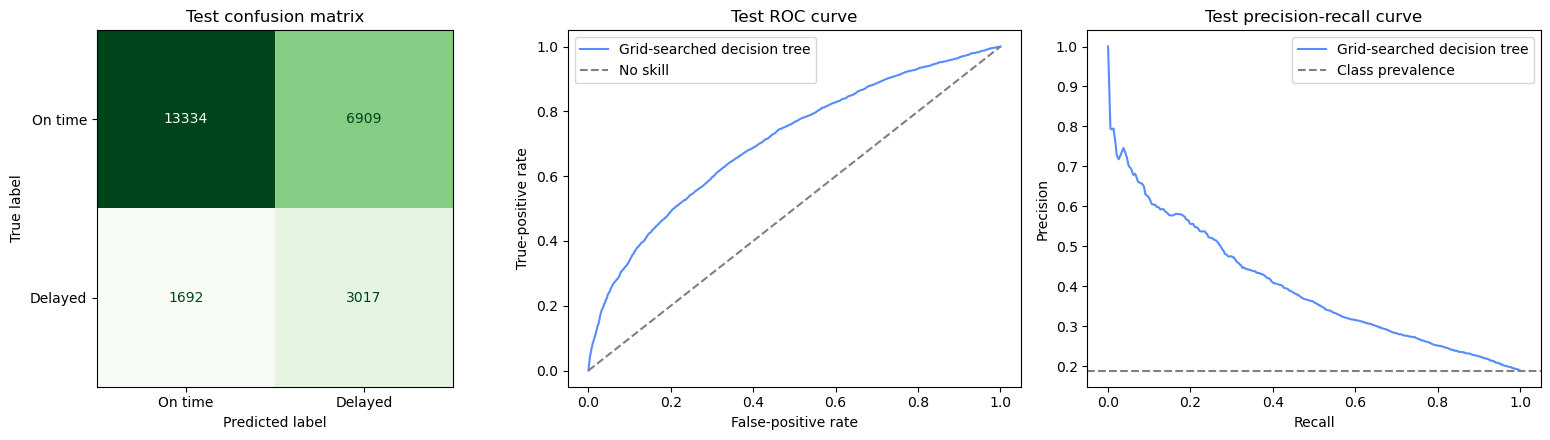

In [22]:
test_predictions = best_decision_tree_pipeline.predict(X_test)
test_probabilities = best_decision_tree_pipeline.predict_proba(X_test)[:, 1]

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_test, test_probabilities)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Greens",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Test confusion matrix")

axes[1].plot(false_positive_rate, true_positive_rate, label="Grid-searched decision tree")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="Test ROC curve")
axes[1].legend()

axes[2].plot(curve_recall, curve_precision, label="Grid-searched decision tree")
axes[2].axhline(y_test.mean(), linestyle="--", color="gray", label="Class prevalence")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Test precision-recall curve")
axes[2].legend()

fig.tight_layout()
plt.show()

## Inspect feature importance

Impurity-based importance shows which encoded inputs most reduced the selected impurity criterion in the refitted best tree. It can favor continuous or high-cardinality predictors, so it should be treated as a diagnostic rather than a causal or definitive feature ranking.

In [23]:
feature_names = best_decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_importance = (
    pd.Series(
        fitted_tree.feature_importances_,
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
    .head(20)
    .to_frame()
)
feature_importance

,importance
numeric__CRSDepTime,0.3034
numeric__HourlyRelativeHumidity,0.1116
numeric__HourlyDewPointTemperature,0.1106
numeric__HourlyDryBulbTemperature,0.0637
numeric__HourlyWindSpeed,0.0532
numeric__CRSElapsedTime,0.0360
numeric__Distance,0.0255
numeric__CRSArrTime,0.0208
categorical__Reporting_Airline_B6,0.0204
numeric__ASPM_CURRENT_SCHEDULED_ARRIVALS,0.0199


## Visualize the top of the tree

The selected tree may contain many levels, so the diagram intentionally shows only the first three levels. This provides an interpretable view of the earliest splits without producing an unreadable full-tree graphic.

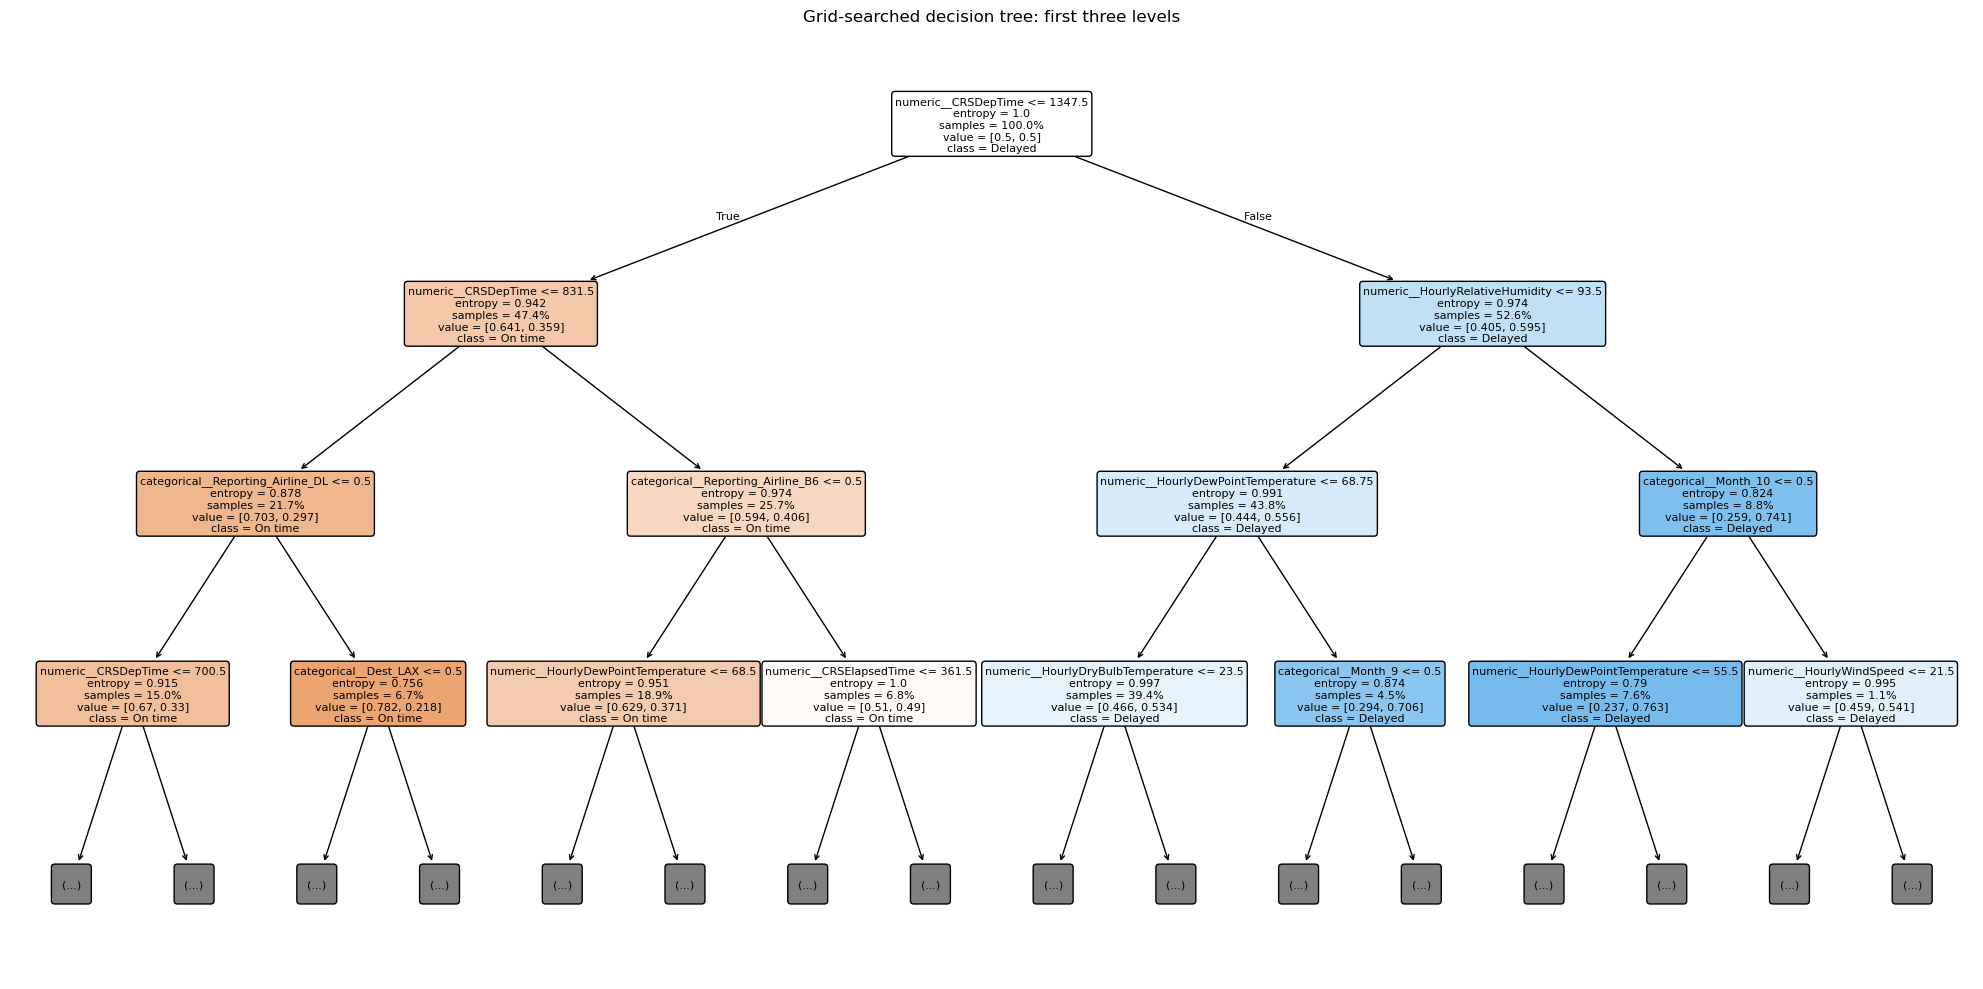

In [24]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["On time", "Delayed"],
    max_depth=3,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Grid-searched decision tree: first three levels")
plt.tight_layout()
plt.show()

## Grid-search interpretation

The cross-validation table explains why the selected hyperparameters won on training data; the held-out test metrics are the primary estimate of generalization. Compare the grid-searched tree with the dummy classifier and the `_01` baselines, paying particular attention to average precision, ROC AUC, delayed-flight recall, and the train-test gap.

The test set must not be used to revise this grid or choose a probability threshold. Threshold selection should use training-only out-of-fold probabilities in a separate experiment. Because this pass uses a random 2019 split, a later phase should also test temporal robustness on later periods.